In [161]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from langdetect import detect

In [112]:
df_reviews = pd.read_excel('C:\\Users\\Користувач\\Desktop\\Project\\materials\\labeled_df.xlsx')

In [113]:
df_reviews.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,716.0,2.97,2021-12-09,2.0,По информационному праву Токарева Ксения Серге...,2021-12-09,2021.0,3.0,neutral,negative,0.0,negative,1.0,0.0,0.0,0.0,0.0
1,University_1,716.0,2.97,2021-09-29,3.0,"Всем добрый день!Хороший университет,но почему...",2021-09-29,2021.0,4.0,positive,neutral,0.0,neutral,NaN,NaN,NaN,NaN,NaN
2,University_1,716.0,2.97,2021-08-25,1.0,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021.0,3.0,neutral,negative,0.0,negative,0.0,1.0,0.0,0.0,0.0
3,University_1,716.0,2.97,2020-06-01,4.0,нормальный университет все прошло хорошо.Кто х...,2020-06-01,2020.0,1.0,negative,positive,0.0,positive,NaN,NaN,NaN,NaN,NaN
4,University_1,716.0,2.97,2020-04-07,5.0,"Читая ваши отзывы про другие кафедры, такое чу...",2020-04-07,2020.0,1.0,negative,positive,0.0,positive,NaN,NaN,NaN,NaN,NaN


# EDA

In [114]:
df_reviews.shape

(1751, 18)

In [115]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751 entries, 0 to 1750
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              1751 non-null   object 
 1   Reviews Count                1675 non-null   float64
 2   Average Rating               1675 non-null   float64
 3   Review Date                  1751 non-null   object 
 4   Review Rating                1675 non-null   float64
 5   Review Text                  1751 non-null   object 
 6   Timestamp                    1675 non-null   object 
 7   Year                         1675 non-null   float64
 8   bert_sentiment               1675 non-null   float64
 9   Sentiment_Category_BERT      1675 non-null   object 
 10  Star_Sentiment_Category      1675 non-null   object 
 11  Match                        1675 non-null   float64
 12  Manual_Category              1749 non-null   object 
 13  Attitude_Towards_S

In [116]:
# Build a DataFrame with only negative reviews
df_neg_labeled = df_reviews[
    (df_reviews["Manual_Category"] == "negative")
]
# Select only the required columns
df_neg_labeled = df_neg_labeled[["Review Text", "Attitude_Towards_Students", "Campus_conditions", "Corruption",	"Academic_Process_Management",	"Education_Quality"]].reset_index(drop=True)
df_neg_labeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Review Text                  510 non-null    object 
 1   Attitude_Towards_Students    510 non-null    float64
 2   Campus_conditions            510 non-null    float64
 3   Corruption                   510 non-null    float64
 4   Academic_Process_Management  510 non-null    float64
 5   Education_Quality            510 non-null    float64
dtypes: float64(5), object(1)
memory usage: 24.0+ KB


In [117]:
df_neg_labeled.isnull().sum()

Review Text                    0
Attitude_Towards_Students      0
Campus_conditions              0
Corruption                     0
Academic_Process_Management    0
Education_Quality              0
dtype: int64

In [118]:
df_neg_labeled['Review Text'].nunique()

509

In [119]:
df_neg_labeled[df_neg_labeled['Review Text'].duplicated(keep=False)]

,Review Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
2,"Шановні вступники, якщо ви хочете зберегти сво...",1.0,1.0,0.0,1.0,1.0
411,"Шановні вступники, якщо ви хочете зберегти сво...",1.0,1.0,0.0,1.0,1.0


In [120]:
df_neg_labeled = df_neg_labeled.drop_duplicates(subset=['Review Text']) # Remove duplicate rows from the dataset.
# This is important to prevent data leakage, especially because we will be using cross-validation.

In [121]:
df_neg_labeled.duplicated().sum()

np.int64(0)

### Text length distribution

In [122]:

def preprocess_text_for_embeddings(text):
    """
    Minimal preprocessing before generating Sentence Embeddings.
    - Keeps casing and punctuation, including hyphens and apostrophes.
    - Replaces censored words (***** ) with a placeholder [CENSORED].
    - Removes extra spaces.
    - Ensures text is a clean string suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""
    
    # Replace censored words with a placeholder
    text = text.replace("*****", "[CENSORED]")
    
    # Remove control characters and weird invisible symbols
    text = re.sub(r"[\x00-\x1f\x7f]", " ", text)
    
    # Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    text = re.sub(r"([.!?])([А-Яа-яA-Za-z0-9])", r"\1 \2", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [123]:
df_neg_labeled["Cleaned_Text"] = df_neg_labeled["Review Text"].apply(preprocess_text_for_embeddings) 

In [124]:
df_neg_labeled.head()

,Review Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text
0,По информационному праву Токарева Ксения Серге...,1.0,0.0,0.0,0.0,0.0,По информационному праву Токарева Ксения Серге...
1,Людоньки це *****. Моя дочку поселили в кімнат...,0.0,1.0,0.0,0.0,0.0,Людоньки це [CENSORED]. Моя дочку поселили в к...
2,"Шановні вступники, якщо ви хочете зберегти сво...",1.0,1.0,0.0,1.0,1.0,"Шановні вступники, якщо ви хочете зберегти сво..."
3,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,0.0,0.0,1.0,0.0,0.0,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...
4,Не знаю як і хто а я звязав своє життя з НАУ я...,0.0,1.0,0.0,0.0,1.0,Не знаю як і хто а я звязав своє життя з НАУ я...


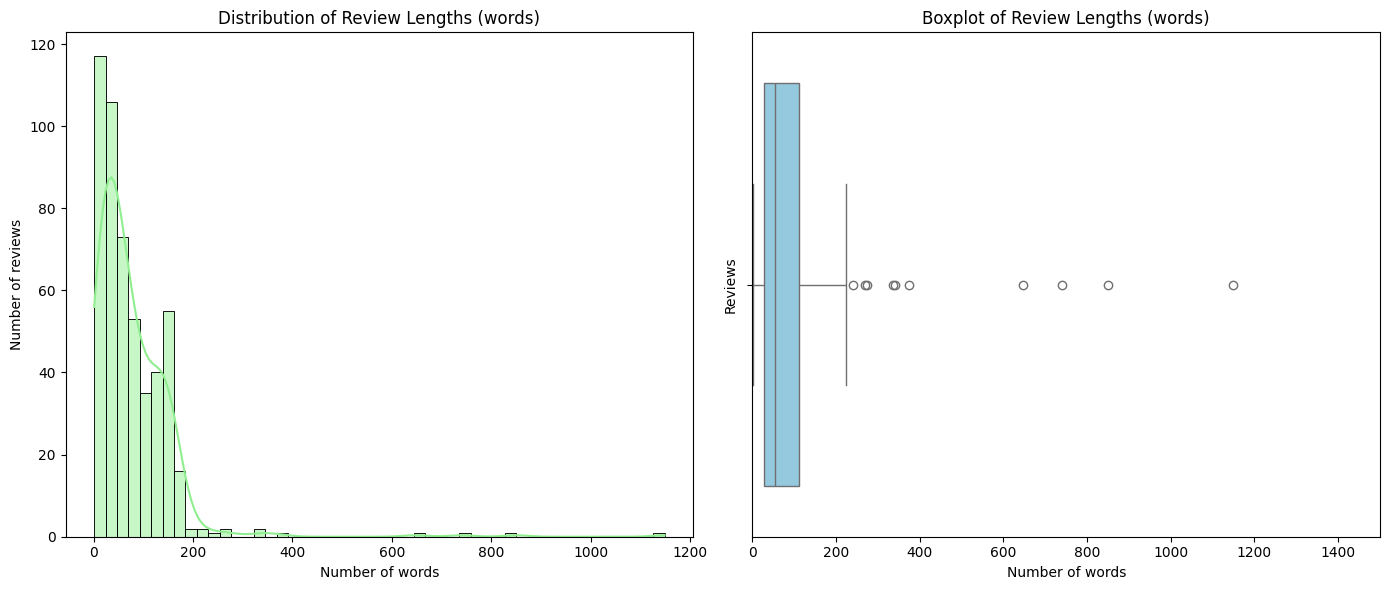

In [125]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 1500

# Compute word counts directly from text
word_lengths = df_neg_labeled["Cleaned_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = df_neg_labeled[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 1500)  # adjust to see the long tail

plt.tight_layout()
plt.show()

### Token Length Distribution

In [126]:
df_neg_labeled["token_length"] = df_neg_labeled["Cleaned_Text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

In [127]:
df_neg_labeled["token_length"].describe()

count     509.000000
mean      135.129666
std       154.235972
min         4.000000
25%        47.000000
50%        96.000000
75%       199.000000
max      1922.000000
Name: token_length, dtype: float64

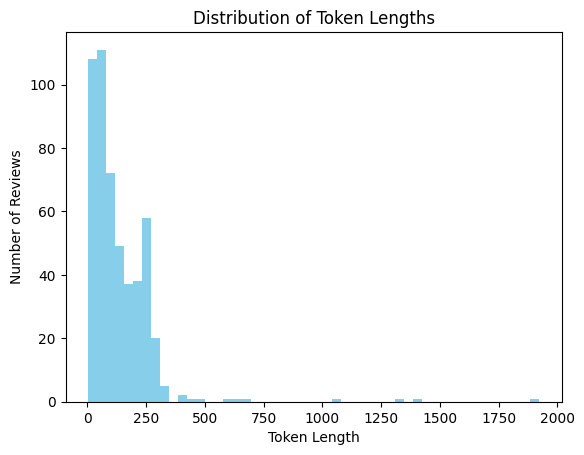

In [128]:
plt.hist(df_neg_labeled["token_length"], bins=50, color='skyblue')
plt.xlabel("Token Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Token Lengths")
plt.show()

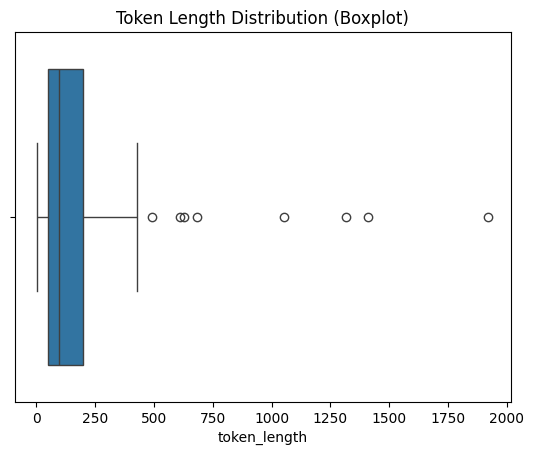

In [129]:
sns.boxplot(x=df_neg_labeled["token_length"])
plt.title("Token Length Distribution (Boxplot)")
plt.show()

In [130]:
(df_neg_labeled["token_length"] > 512).sum()

np.int64(7)

Token indices sequence length is longer than the specified maximum sequence length for this model (266 > 128). Running this sequence through the model will result in indexing errors


count     509.000000
mean      135.129666
std       154.235972
min         4.000000
25%        47.000000
50%        96.000000
75%       199.000000
max      1922.000000
Name: token_length, dtype: float64
Number of texts that would be truncated:
max_length=128: 202 texts
max_length=256: 63 texts
max_length=512: 7 texts


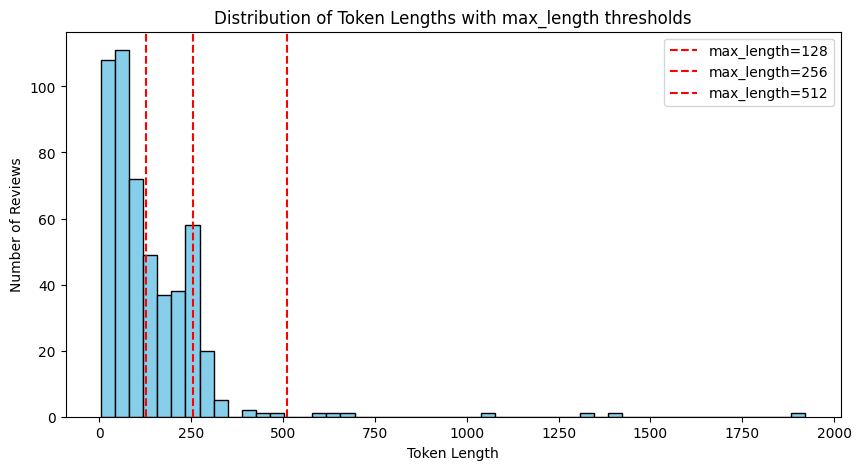

Embeddings shape: torch.Size([509, 768])


In [107]:

# 1️⃣ Load the MPNet model
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
tokenizer = model.tokenizer

# 2️⃣ Calculate token length for each text (for EDA) using .tokenize() to avoid max_length issues
df_neg_labeled["token_length"] = df_neg_labeled["Cleaned_Text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

# 3️⃣ View basic statistics of token lengths
print(df_neg_labeled["token_length"].describe())

# 4️⃣ Count how many texts would be truncated at different max_length thresholds
max_lengths = [128, 256, 512]
truncated_counts = [(df_neg_labeled["token_length"] > ml).sum() for ml in max_lengths]

print("Number of texts that would be truncated:")
for ml, cnt in zip(max_lengths, truncated_counts):
    print(f"max_length={ml}: {cnt} texts")

# 5️⃣ Plot the distribution of token lengths and mark max_length thresholds
plt.figure(figsize=(10,5))
plt.hist(df_neg_labeled["token_length"], bins=50, color='skyblue', edgecolor='black')
for ml in max_lengths:
    plt.axvline(ml, color='red', linestyle='--', label=f'max_length={ml}')
plt.xlabel("Token Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Token Lengths with max_length thresholds")
plt.legend()
plt.show()

# 6️⃣ Generate embeddings with MPNet, setting max_length to 512 to minimize truncation
# Short texts are fully processed; only extremely long texts are truncated
texts = df_neg_labeled["Cleaned_Text"].tolist()
embeddings = model.encode(
    texts,
    convert_to_tensor=True,
    max_length=512,   # MPNet physical limit
    truncation=True   # truncate only texts longer than max_length
)

print(f"Embeddings shape: {embeddings.shape}")

We set max_seq_length=512 because MPNet can handle up to 512 tokens, which preserves most of the information in the reviews. Reviews longer than 512 tokens are removed instead of truncated to avoid losing content that may be important for multi-label targets. This ensures that the model trains only on complete and correct data.

Removed 0 texts longer than 512 tokens
Removed 0 texts shorter than 10 tokens
Remaining texts: 490
count    490.000000
mean     124.661224
std       90.587943
min       10.000000
25%       50.500000
50%       98.000000
75%      198.000000
max      492.000000
Name: token_length, dtype: float64


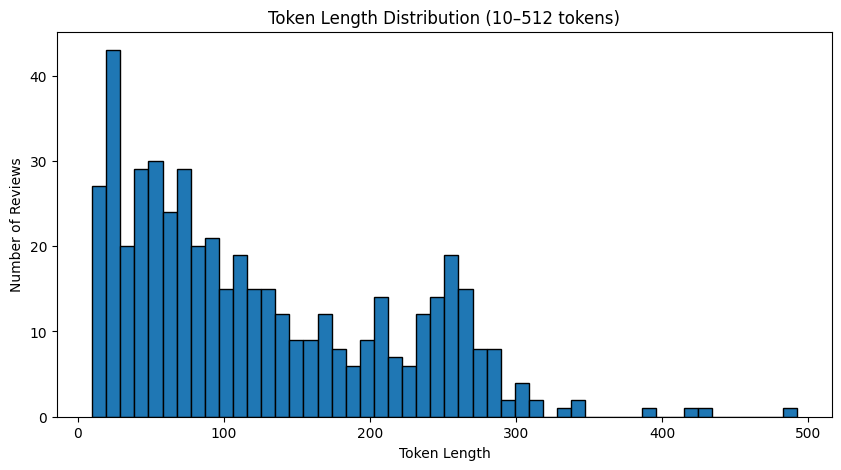

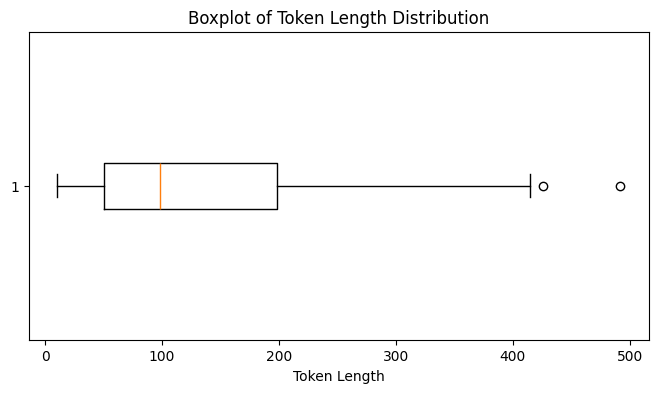

In [136]:
# Define limits
min_tokens = 10
max_seq_length = 512

original_size = len(df_neg_labeled)

# Remove texts longer than 512 tokens
df_neg_labeled = df_neg_labeled[df_neg_labeled["token_length"] <= max_seq_length]
print(f"Removed {original_size - len(df_neg_labeled)} texts longer than {max_seq_length} tokens")

size_after_long_filter = len(df_neg_labeled)

# Remove texts shorter than 20 tokens
df_neg_labeled = df_neg_labeled[df_neg_labeled["token_length"] >= min_tokens]
print(f"Removed {size_after_long_filter - len(df_neg_labeled)} texts shorter than {min_tokens} tokens")

print(f"Remaining texts: {len(df_neg_labeled)}")

# Show new distribution
print(df_neg_labeled["token_length"].describe())

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(df_neg_labeled["token_length"], bins=50, edgecolor='black')
plt.xlabel("Token Length")
plt.ylabel("Number of Reviews")
plt.title(f"Token Length Distribution ({min_tokens}–{max_seq_length} tokens)")
plt.show()

# Boxplot to visualize spread and potential outliers
plt.figure(figsize=(8,4))
plt.boxplot(df_neg_labeled["token_length"], vert=False)
plt.xlabel("Token Length")
plt.title("Boxplot of Token Length Distribution")
plt.show()

In [134]:
df_neg_labeled["token_length"].quantile([0.05, 0.25, 0.5, 0.75, 0.9, 0.95])

0.05     18.45
0.25     50.50
0.50     98.00
0.75    198.00
0.90    258.10
0.95    279.00
Name: token_length, dtype: float64

Token length distribution was analyzed using histograms and boxplots. Most reviews fall within a moderate token range, while extremely short (<10 tokens) and very long (>512 tokens) texts were removed to ensure the model trains on informative and processable inputs.

### Class imbalance

Можливі рішення:

oversampling

class weights

balanced sampling

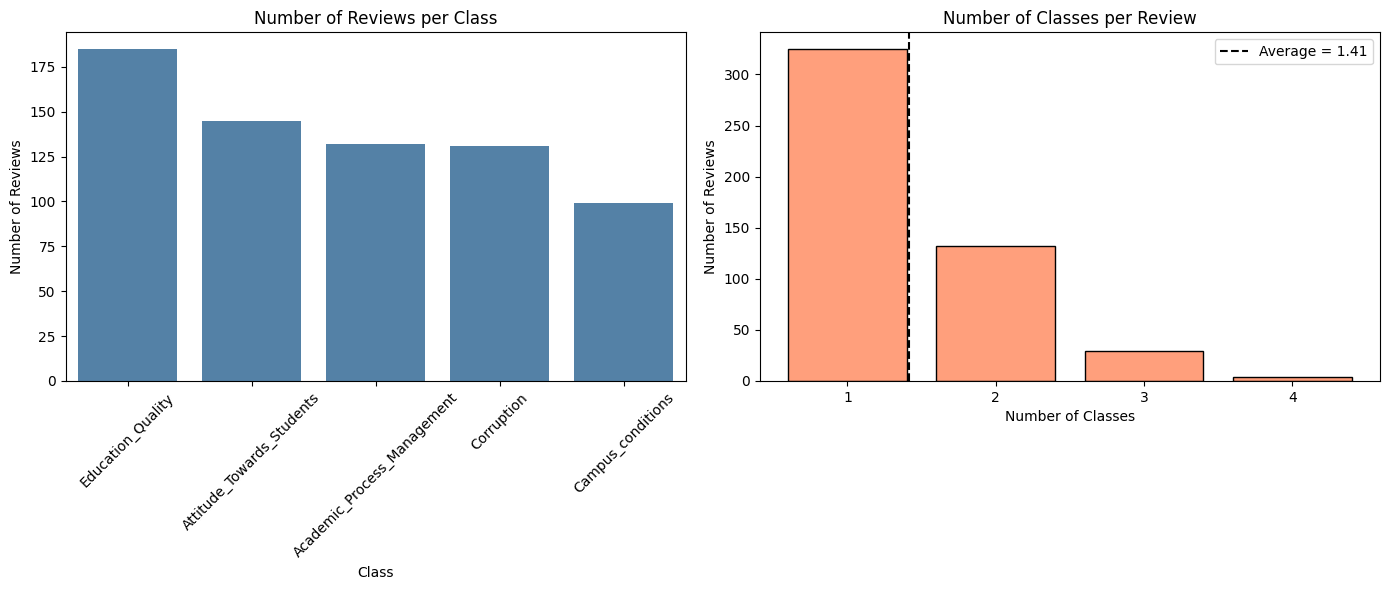

In [139]:
# Columns representing the classes
class_cols = [
    'Attitude_Towards_Students',
    'Campus_conditions',
    'Corruption',
    'Academic_Process_Management',
    'Education_Quality'
]

# 1️⃣ Count of reviews per class
class_counts = df_neg_labeled[class_cols].sum().sort_values(ascending=False)
plot_df_counts = class_counts.reset_index()
plot_df_counts.columns = ['Class', 'Count']

# 2️⃣ Number of classes per review
num_classes = df_neg_labeled[class_cols].sum(axis=1)
max_classes = int(num_classes.max())
bins = range(1, max_classes + 2)

# Calculate the average number of classes per review
avg_classes = num_classes.mean()

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — bar plot of counts per class
sns.barplot(data=plot_df_counts, x='Class', y='Count', color='steelblue', ax=axes[0])
axes[0].set_title("Number of Reviews per Class")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xlabel("Class")
axes[0].tick_params(axis='x', rotation=45)

# Right plot — histogram of number of classes per review
sns.histplot(num_classes, bins=bins, color='coral', discrete=True, shrink=0.8, ax=axes[1])
axes[1].axvline(avg_classes, color='black', linestyle='--', label=f"Average = {avg_classes:.2f}")
axes[1].set_title("Number of Classes per Review")
axes[1].set_xlabel("Number of Classes")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(bins[:-1])
axes[1].legend()

plt.tight_layout()
plt.show()

### Create a co-occurrence matrix
- This shows how often different categories are labeled together by users
-  Understanding these patterns can directly influence model architecture decisions
- The interpretation of the results

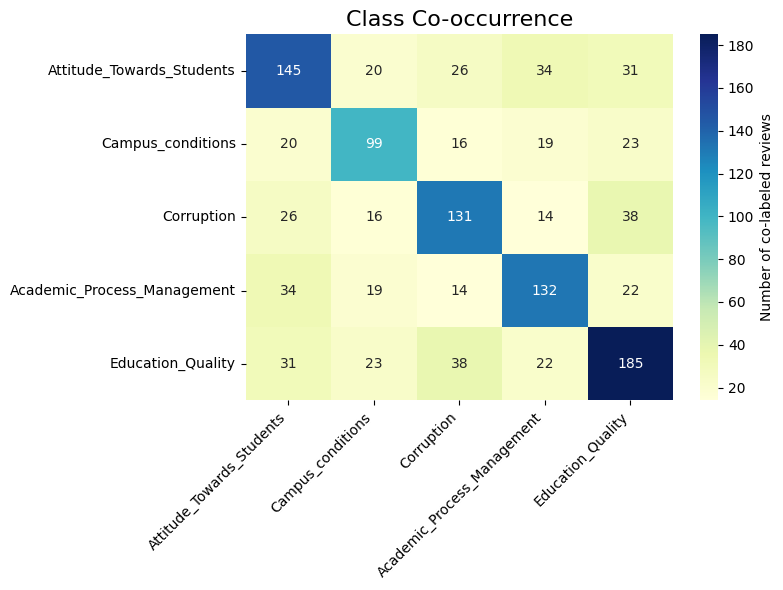

In [140]:
co_occurrence = df_neg_labeled[class_cols].T.dot(df_neg_labeled[class_cols])

# Convert to integer so heatmap annotations work properly
co_occurrence = co_occurrence.astype(int)

# Visualize co-occurrence matrix as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    co_occurrence,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of co-labeled reviews'}
)
plt.title("Class Co-occurrence", fontsize=16)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Distribution Across Languages

Before training a multi-label classification model, it's important to ensure that categories are not biased by language.
If certain categories appear predominantly in one language (e.g., Russian vs. Ukrainian), the model might learn to predict the language rather than the actual features of the review.

The following analysis examines how each review category is distributed between Ukrainian and Russian reviews.

In [142]:
# Define a safe detection function
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Apply to the review text column
df_neg_labeled["Language"] = df_neg_labeled["Review Text"].apply(detect_lang)

In [143]:
df_neg_labeled.head()

,Review Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,token_length,Language
0,По информационному праву Токарева Ксения Серге...,1.0,0.0,0.0,0.0,0.0,По информационному праву Токарева Ксения Серге...,42,ru
1,Людоньки це *****. Моя дочку поселили в кімнат...,0.0,1.0,0.0,0.0,0.0,Людоньки це [CENSORED]. Моя дочку поселили в к...,70,uk
2,"Шановні вступники, якщо ви хочете зберегти сво...",1.0,1.0,0.0,1.0,1.0,"Шановні вступники, якщо ви хочете зберегти сво...",266,uk
3,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,0.0,0.0,1.0,0.0,0.0,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,44,ru
4,Не знаю як і хто а я звязав своє життя з НАУ я...,0.0,1.0,0.0,0.0,1.0,Не знаю як і хто а я звязав своє життя з НАУ я...,201,uk


In [150]:
# Count how many reviews of each category appear in each language
lang_category_counts = df_neg_labeled.groupby("Language")[class_cols].sum()

lang_category_counts

,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
Language,,,,,
bg,0.0,0.0,1.0,0.0,0.0
ru,61.0,54.0,57.0,46.0,80.0
uk,84.0,45.0,73.0,86.0,105.0


In [151]:
lang_category_percent = lang_category_counts.div(
    lang_category_counts.sum(axis=0), axis=1
)
lang_category_percent

,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
Language,,,,,
bg,0.00000,0.000000,0.007634,0.000000,0.000000
ru,0.42069,0.545455,0.435115,0.348485,0.432432
uk,0.57931,0.454545,0.557252,0.651515,0.567568


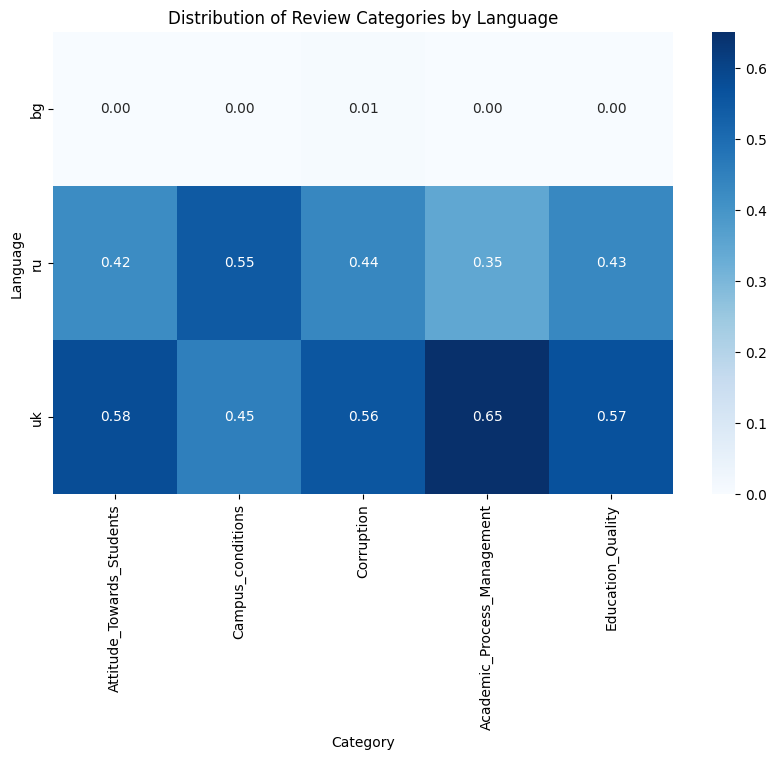

In [152]:
plt.figure(figsize=(10,6))

sns.heatmap(
    lang_category_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Distribution of Review Categories by Language")
plt.xlabel("Category")
plt.ylabel("Language")

plt.show()

A heatmap was used to analyze how review categories are distributed across languages.
This analysis helps detect potential language bias in the dataset.
If certain categories appear predominantly in one language, the model may learn language patterns instead of the semantic meaning of the reviews.

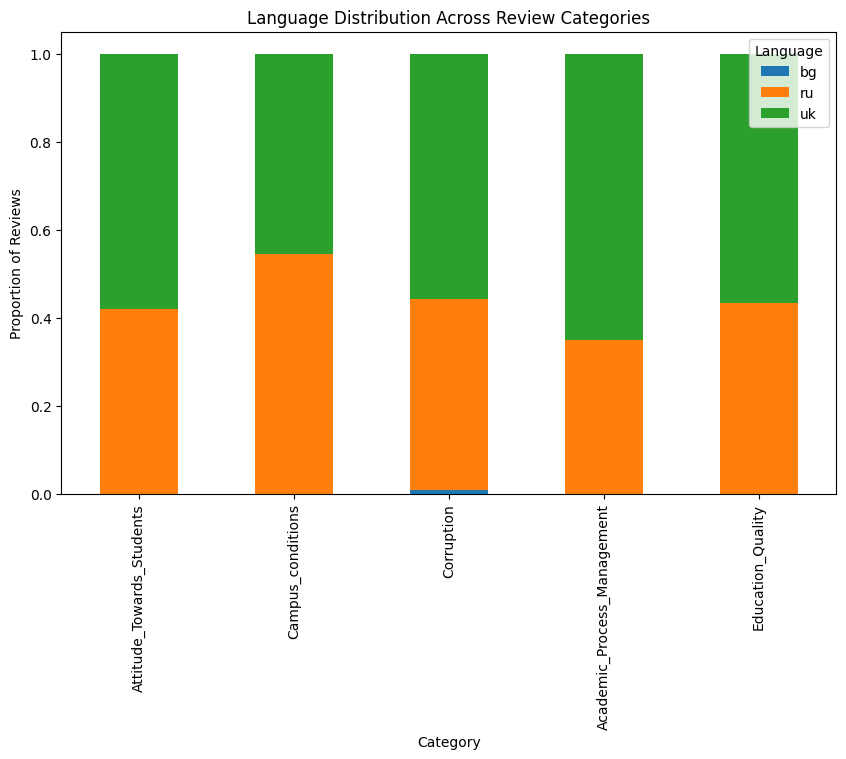

In [153]:
lang_category_percent.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Language Distribution Across Review Categories")
plt.xlabel("Category")
plt.ylabel("Proportion of Reviews")
plt.legend(title="Language")

plt.show()

### Top words frequency


In [157]:
all_words = " ".join(df_neg_labeled["Cleaned_Text"]).split()

unique_words = len(set(all_words))
total_words = len(all_words)

vocab_richness = unique_words / total_words
print(vocab_richness)

0.4148838013955366


The Type–Token Ratio (TTR) of the dataset is 0.41, indicating relatively high lexical diversity in the review texts.

### Rare words ratio


In [158]:
from collections import Counter

word_counts = Counter(all_words)

rare_words = [w for w, c in word_counts.items() if c == 1]

rare_ratio = len(rare_words) / len(word_counts)

print(rare_ratio)

0.7619709500312739


About 76% of unique words appear only once, which is normal for user-generated reviews and does not pose a problem for transformer-based models

### Zipf plot

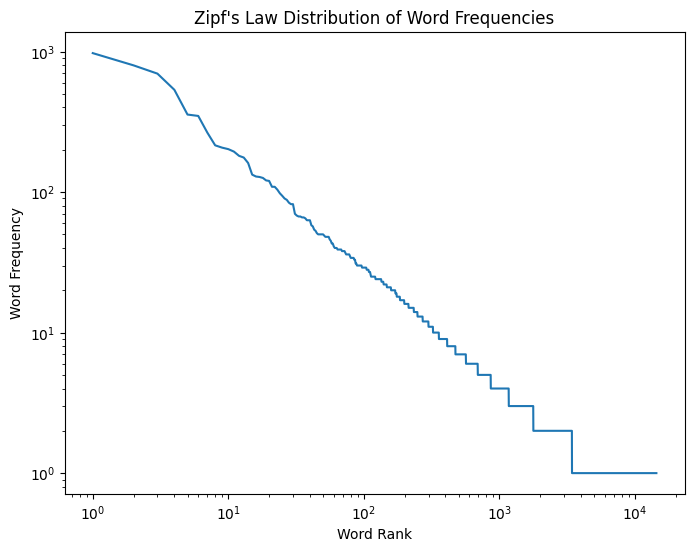

In [162]:
# Count word frequencies
word_counts = Counter(all_words)

# Sort frequencies
freqs = sorted(word_counts.values(), reverse=True)

# Generate ranks
ranks = np.arange(1, len(freqs) + 1)

# Plot Zipf curve
plt.figure(figsize=(8,6))
plt.loglog(ranks, freqs)

plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Zipf's Law Distribution of Word Frequencies")

plt.show()

Zipf’s law is mostly followed; small zigzags in the tail correspond to rare or misspelled words, which is normal for user-generated text.